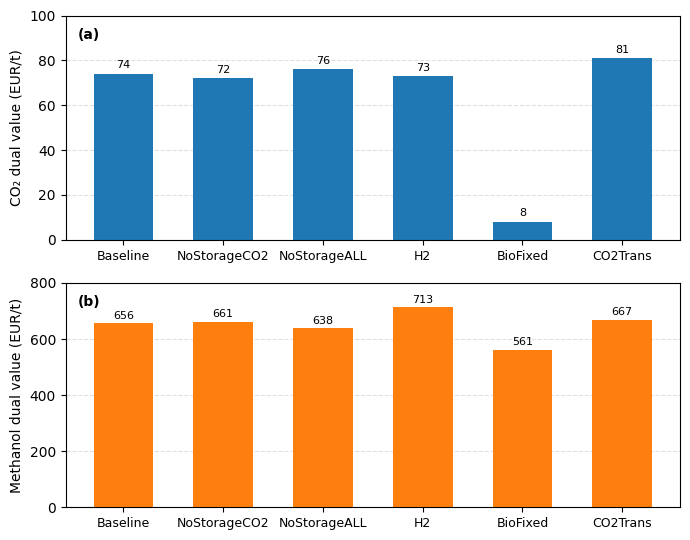

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.offsetbox import AnchoredText

# --- Load data ---
file = '../Scenario_Analysis.xlsx'
df_co2 = pd.read_excel(file, sheet_name='CO2Duals')
df_co2 = df_co2.loc[:, ~df_co2.columns.str.contains(r'\.\d+$')]
df_co2 = df_co2.set_index(df_co2.columns[0])
dt_index = pd.Timestamp("2019-01-01") + pd.to_timedelta(df_co2.index - 1, unit="h")
df_co2.index = dt_index
df_co2.index.name = "datetime"

df_meoh = pd.read_excel(file, sheet_name='MethanolMarginal')
df_meoh = df_meoh.loc[:, ~df_meoh.columns.str.contains(r'\.\d+$')]
df_meoh = df_meoh.set_index(df_meoh.columns[0])
scenario_cols = [c for c in df_meoh.columns if c != "ElectricityPrice"]

# --- Scenario Order ---
scenarios = ['Baseline', 'NoStorageCO2', 'NoStorageALL', 'H2', 'BioFixed', 'CO2Trans']
x_pos = range(len(scenarios))

# --- Compute Averages ---
co2_means = df_co2.mean().round().reindex(scenarios)
meoh_means = df_meoh[scenario_cols].mean().round().reindex(scenarios)

# --- Plot Settings ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.5))
fig.subplots_adjust(hspace=0.6)

bar_width = 0.6
label_fontsize = 10
tick_fontsize = 9
value_fontsize = 8

# --- CO₂ Duals ---
ax1.bar(x_pos, co2_means.values, width=bar_width, color='tab:blue')
ax1.set_ylabel("CO₂ dual value (EUR/t)", fontsize=label_fontsize)
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 20))
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(scenarios, fontsize=tick_fontsize)

for i, value in enumerate(co2_means.values):
    val = f"{value:.1f}" if value % 1 else f"{int(value)}"
    ax1.text(i, value + 1.5, val, ha='center', va='bottom', fontsize=value_fontsize)

# --- Methanol Duals ---
ax2.bar(x_pos, meoh_means.values, width=bar_width, color='tab:orange')
ax2.set_ylabel("Methanol dual value (EUR/t)", fontsize=label_fontsize)
ax2.set_ylim(0, 800)
ax2.set_yticks(range(0, 801, 200))
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(scenarios, fontsize=tick_fontsize)

for i, value in enumerate(meoh_means.values):
    ax2.text(i, value + 10, f"{int(value)}", ha='center', va='bottom', fontsize=value_fontsize)

ax1.add_artist(AnchoredText("(a)", loc='upper left', prop=dict(size=10, weight='bold'), frameon=False))
ax2.add_artist(AnchoredText("(b)", loc='upper left', prop=dict(size=10, weight='bold'), frameon=False))

# --- Export ---
plt.tight_layout()
plt.savefig("DualValues_FinalClean.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()


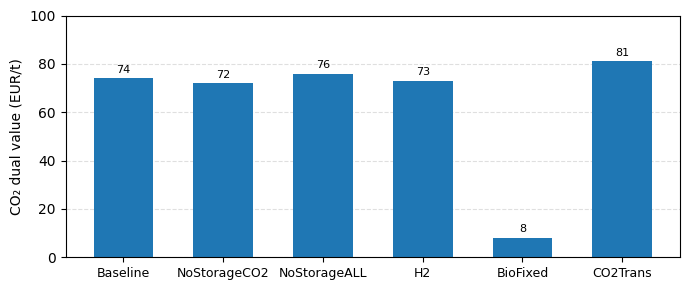

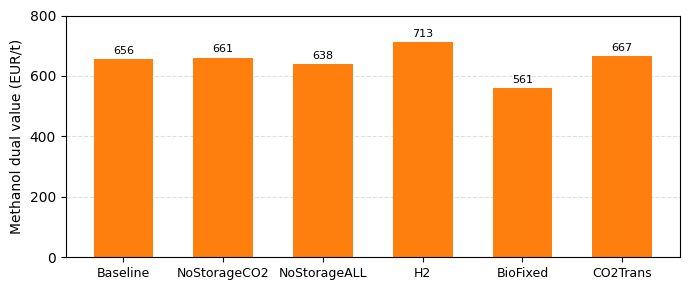

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.offsetbox import AnchoredText

# --- Load data ---
file = '../Scenario_Analysis.xlsx'
df_co2 = pd.read_excel(file, sheet_name='CO2Duals')
df_co2 = df_co2.loc[:, ~df_co2.columns.str.contains(r'\.\d+$')]
df_co2 = df_co2.set_index(df_co2.columns[0])
dt_index = pd.Timestamp("2019-01-01") + pd.to_timedelta(df_co2.index - 1, unit="h")
df_co2.index = dt_index
df_co2.index.name = "datetime"

df_meoh = pd.read_excel(file, sheet_name='MethanolMarginal')
df_meoh = df_meoh.loc[:, ~df_meoh.columns.str.contains(r'\.\d+$')]
df_meoh = df_meoh.set_index(df_meoh.columns[0])
scenario_cols = [c for c in df_meoh.columns if c != "ElectricityPrice"]

# --- Scenario Order ---
scenarios = ['Baseline', 'NoStorageCO2', 'NoStorageALL', 'H2', 'BioFixed', 'CO2Trans']
x_pos = range(len(scenarios))

# --- Compute Averages ---
co2_means = df_co2.mean().round().reindex(scenarios)
meoh_means = df_meoh[scenario_cols].mean().round().reindex(scenarios)

# ---------- FIGURE (a): CO2 ----------
fig1, ax1 = plt.subplots(figsize=(7, 3))

ax1.bar(x_pos, co2_means.values, width=bar_width, color='tab:blue')
ax1.set_ylabel("CO₂ dual value (EUR/t)", fontsize=label_fontsize)
ax1.set_ylim(0, 100)
ax1.set_yticks(range(0, 101, 20))
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(scenarios, fontsize=tick_fontsize)

for i, value in enumerate(co2_means.values):
    val = f"{value:.1f}" if value % 1 else f"{int(value)}"
    ax1.text(i, value + 1.5, val, ha='center', va='bottom', fontsize=value_fontsize)

plt.tight_layout()
plt.savefig("DualValues_CO2.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()


# ---------- FIGURE (b): Methanol ----------
fig2, ax2 = plt.subplots(figsize=(7, 3))

ax2.bar(x_pos, meoh_means.values, width=bar_width, color='tab:orange')
ax2.set_ylabel("Methanol dual value (EUR/t)", fontsize=label_fontsize)
ax2.set_ylim(0, 800)
ax2.set_yticks(range(0, 801, 200))
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(scenarios, fontsize=tick_fontsize)

for i, value in enumerate(meoh_means.values):
    ax2.text(i, value + 10, f"{int(value)}", ha='center', va='bottom', fontsize=value_fontsize)

plt.tight_layout()
plt.savefig("DualValues_Methanol.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

